Will the removal of level crossings and related transport improvements along the Upfield line drive faster house price growth in treated suburbs compared with untreated suburbs?

Focusing on three main variables:
- Suburb
- House price
- Population density

# Visualisations

The suburbs will be separated into two groups, "Treated" and "Untreated" based on their distance to the closest LXRP site.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

YEARS = list(range(2015, 2025))
YEAR_STR = [str(y) for y in YEARS]

project_root = Path.cwd()
if not (project_root / "data" / "clean").exists():
    project_root = project_root.parent

clean = project_root / "data" / "clean"

# Load treated and untreated house prices
treated_prices_df = pd.read_csv(clean / "house_prices_treated_suburbs.csv")
untreated_prices_df = pd.read_csv(clean / "house_prices_untreated_suburbs.csv")

# Add group labels
treated_prices_df['Group'] = 'Treated'
untreated_prices_df['Group'] = 'Untreated'

# Combine for "all suburbs"
all_prices_df = pd.concat([treated_prices_df, untreated_prices_df], ignore_index=True)

# Normalize suburb names for consistency
for df in [treated_prices_df, untreated_prices_df, all_prices_df]:
    df['Suburb'] = df['suburb'].str.strip().str.title()

# Create wide format for price data using year columns
price_wide = all_prices_df[['Suburb'] + YEAR_STR].copy()
price_wide[YEAR_STR] = price_wide[YEAR_STR].apply(pd.to_numeric, errors="coerce")

log_price_wide = price_wide.copy()
log_price_wide[YEAR_STR] = np.log(log_price_wide[YEAR_STR])

# Load population density data from the original density file
density_long = pd.read_csv(clean / "requested_suburbs_density_2015_2024_long.csv").rename(
    columns={"requested_suburb": "Suburb", "year": "Year", "density": "Density"}
)
density_long["Suburb"] = density_long["Suburb"].astype(str).str.strip().str.title()
density_long["Year"] = pd.to_numeric(density_long["Year"], errors="coerce").astype(int)
density_long["Density"] = pd.to_numeric(density_long["Density"], errors="coerce")

# Reconstruct a wide density table
density_wide = (
    density_long.pivot(index="Suburb", columns="Year", values="Density")
    .reindex(columns=YEARS)
    .reset_index()
)
density_wide.columns = ["Suburb"] + YEAR_STR

# Extract treated and untreated suburbs from the loaded data
treated_suburbs = treated_prices_df['Suburb'].unique().tolist()
untreated_suburbs = untreated_prices_df['Suburb'].unique().tolist()

treated_df = log_price_wide[log_price_wide["Suburb"].isin(treated_suburbs)].copy()
untreated_df = log_price_wide[log_price_wide["Suburb"].isin(untreated_suburbs)].copy()
all_suburbs_df = log_price_wide.copy()

price_long = log_price_wide.melt(
    id_vars="Suburb",
    value_vars=YEAR_STR,
    var_name="Year",
    value_name="log_HousePrice",
)
price_long["Suburb"] = price_long["Suburb"].astype(str).str.strip().str.title()
price_long["Year"] = pd.to_numeric(price_long["Year"], errors="coerce").astype(int)
price_long["log_HousePrice"] = pd.to_numeric(price_long["log_HousePrice"], errors="coerce")

price_grouped_yearly = price_long.groupby(["Year", "Suburb"], as_index=False).agg(
    log_HousePrice=("log_HousePrice", "median"),
)
price_grouped_yearly["Group"] = "Unclassified"
price_grouped_yearly.loc[price_grouped_yearly["Suburb"].isin(treated_suburbs), "Group"] = "Treated"
price_grouped_yearly.loc[price_grouped_yearly["Suburb"].isin(untreated_suburbs), "Group"] = "Untreated"
price_grouped_yearly = price_grouped_yearly[price_grouped_yearly["Group"].isin(["Treated", "Untreated"])].copy()
price_grouped_yearly = price_grouped_yearly.groupby(["Year", "Group"], as_index=False).agg(
    log_HousePriceMedian=("log_HousePrice", "median"),
)

panel = price_long.merge(density_long[["Suburb", "Year", "Density"]], on=["Suburb", "Year"], how="inner")

panel["Group"] = "Unclassified"
panel.loc[panel["Suburb"].isin(treated_suburbs), "Group"] = "Treated"
panel.loc[panel["Suburb"].isin(untreated_suburbs), "Group"] = "Untreated"
panel = panel[panel["Group"].isin(["Treated", "Untreated"])].copy()

panel["log_Density"] = np.log(panel["Density"].clip(lower=1e-9))

grouped_yearly = panel.groupby(["Year", "Group"], as_index=False).agg(
    log_HousePriceMedian=("log_HousePrice", "median"),
    DensityMedian=("Density", "median"),
)

**Median house price by suburb (2015 to 2024)**

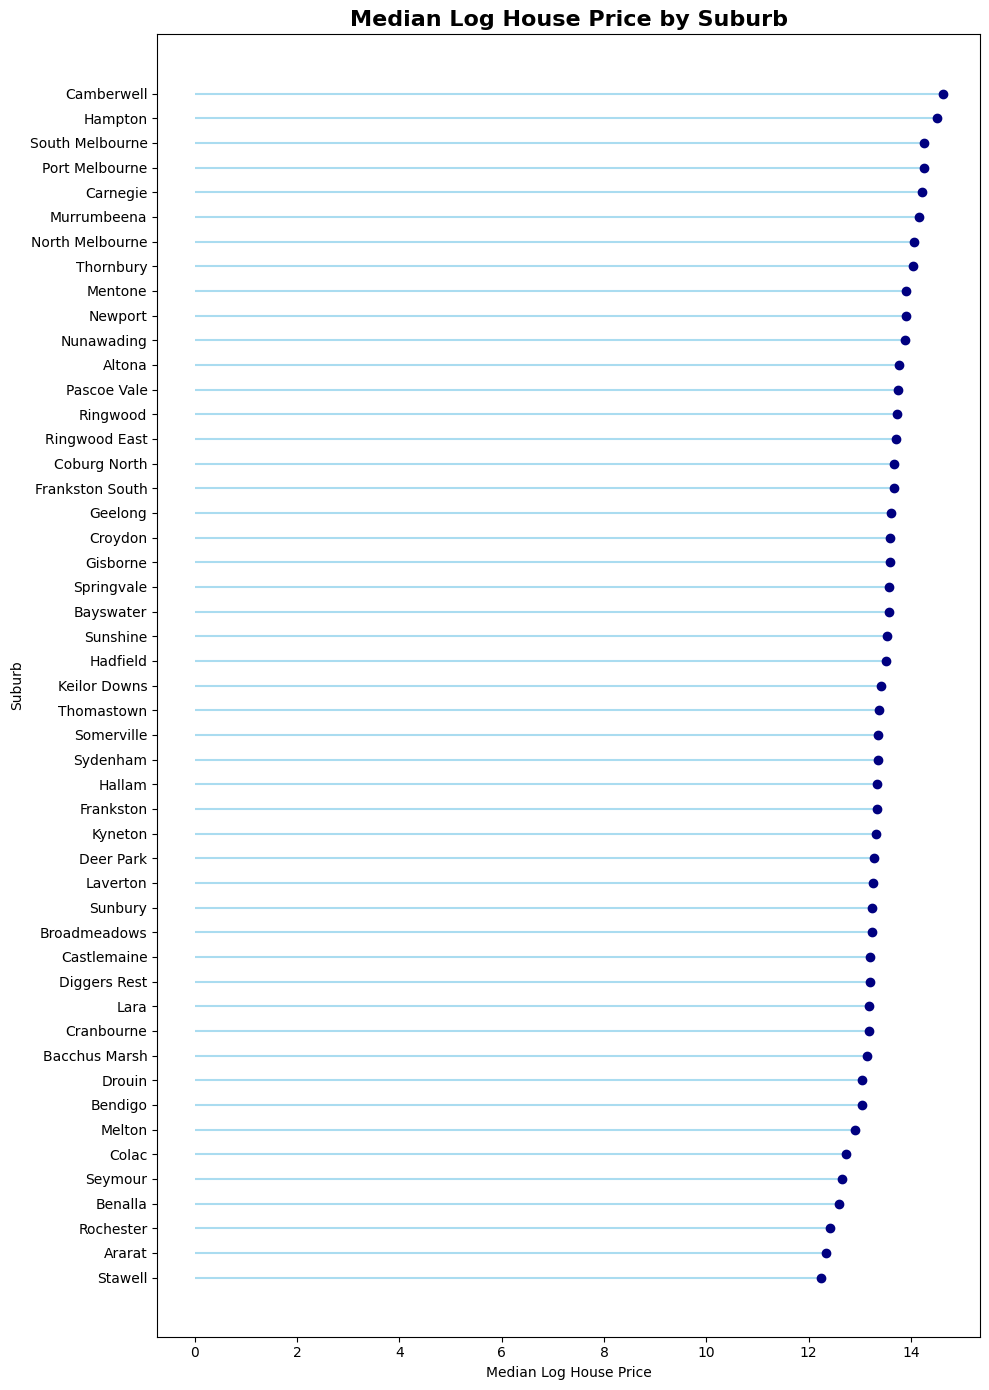

In [3]:
eda = all_suburbs_df.copy()

eda = eda.melt(
    id_vars="Suburb",
    var_name="Year",
    value_name="log_HousePrice"
)

eda["log_HousePrice"] = pd.to_numeric(eda["log_HousePrice"], errors="coerce")
eda = eda.dropna()

import matplotlib.pyplot as plt

# Median log house price by suburb
suburb_median = (
    eda.groupby("Suburb", as_index=False)["log_HousePrice"]
    .median()
    .sort_values("log_HousePrice", ascending=True)
)

plt.figure(figsize=(10,14))

# Lines
plt.hlines(
    y=suburb_median["Suburb"],
    xmin=0,
    xmax=suburb_median["log_HousePrice"],
    color="skyblue",
    alpha=0.7
)

# Dots
plt.plot(
    suburb_median["log_HousePrice"],
    suburb_median["Suburb"],
    "o",
    color="navy"
)

plt.title("Median Log House Price by Suburb", fontsize=16, weight="bold")
plt.xlabel("Median Log House Price")
plt.ylabel("Suburb")
plt.tight_layout()
plt.show()

This figure ranks suburbs by their **median log house price** over the sample period.

Suburbs at the top, such as **Camberwell, Hampton, South Melbourne, Port Melbourne, Carnegie, and Murrumbeena**, have the highest typical house prices. Suburbs near the bottom, such as **Stawell, Ararat, Rochester, Benalla, Seymour, and Colac**, have the lowest typical house prices.

Because the x-axis is in **log house prices**, differences should be interpreted proportionally. A higher value means substantially higher median house prices, but not in direct dollar units. For example, a difference of `0.10` log points is roughly a 10% difference in house prices.

The graph shows clear variation across suburbs. Inner-city and higher-demand Melbourne suburbs tend to sit near the top, while regional or outer suburbs tend to sit lower. This suggests that suburb location and baseline market desirability are important sources of house-price differences.

For your analysis, this supports the use of **suburb fixed effects** in the DiD regression, because suburbs clearly differ in their baseline price levels. The graph is descriptive: it shows ranking and variation, but it does not show a causal treatment effect.

**Box & Whisker plot (treated and untreated suburbs with their median house prices)**

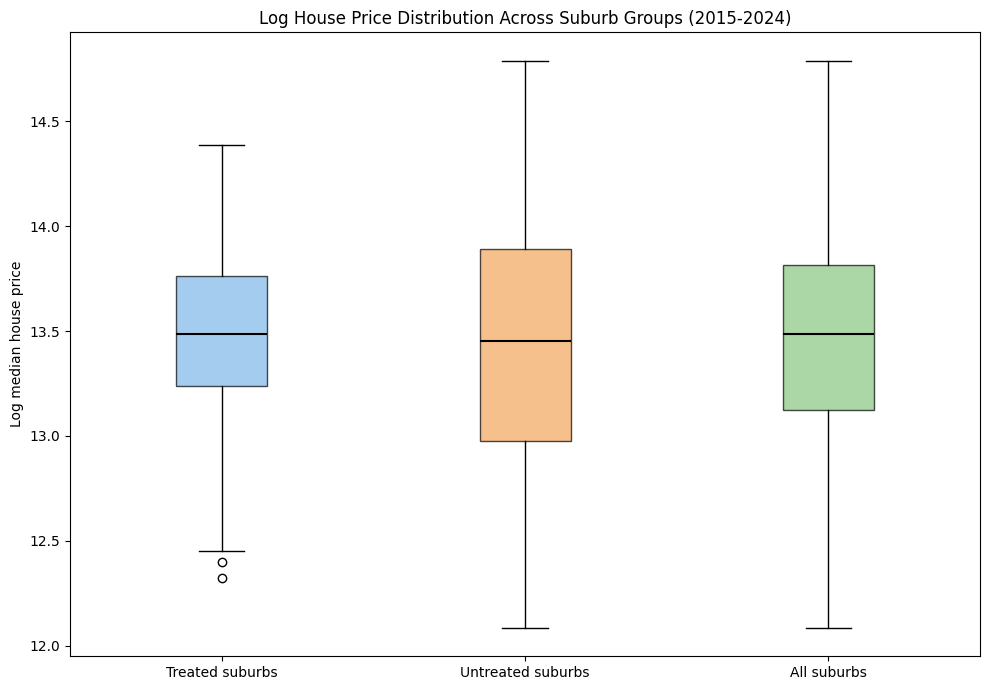

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root reliably whether or not earlier cells were run.
if "project_root" in globals():
    root = Path(project_root)
else:
    root = Path.cwd()

year_cols = YEAR_STR

# Stack each suburb group into a single year-level distribution, using log prices.
def values_from_wide(df):
    values = df[year_cols].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()
    return pd.Series(values).dropna().values

treated_values = values_from_wide(treated_df)
untreated_values = values_from_wide(untreated_df)
all_values = values_from_wide(all_suburbs_df)

fig, ax = plt.subplots(figsize=(10, 7))
box = ax.boxplot(
    [treated_values, untreated_values, all_values],
    tick_labels=["Treated suburbs", "Untreated suburbs", "All suburbs"],
    showfliers=True,
    patch_artist=True,
)

colors = ["#7db7e8", "#f2a65a", "#88c57f"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

ax.set_ylabel("Log median house price")
ax.set_title("Log House Price Distribution Across Suburb Groups (2015-2024)")
plt.tight_layout()
plt.show()

This boxplot compares the distribution of **log median house prices** across treated suburbs, untreated suburbs, and all suburbs from 2015 to 2024.

The median log house price for **treated suburbs** is slightly higher than for **untreated suburbs**. This suggests that, on average, treated suburbs had somewhat higher house prices over the period.

The **untreated suburbs** have a wider spread. Their box and whiskers extend further, meaning there is more variation in house prices among untreated suburbs. This likely reflects the fact that the untreated group includes a broader mix of lower-price and higher-price suburbs, including more regional or outer-area locations.

The **treated suburbs** are more tightly clustered. Their interquartile range is narrower, meaning the middle 50% of treated-suburb observations are more similar in price. There are also a few low-price outliers among treated suburbs.

The **all suburbs** category sits between the two groups because it combines both treated and untreated observations.

Overall, the figure shows that treated and untreated suburbs do not have identical baseline price distributions. This supports the need for controls and fixed effects in the DiD regression, because simple comparisons of average prices could be misleading. The plot is descriptive only; it shows differences in distributions, not a causal treatment effect.

**Box and whisker plot for population density across all suburbs**

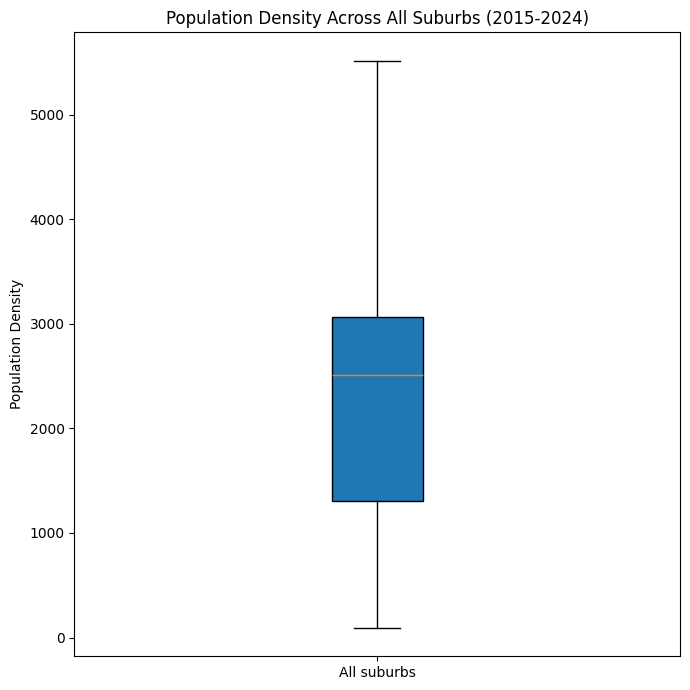

In [5]:
density_cols = [col for col in density_wide.columns if col not in ["Suburb"]]
density_values = density_wide[density_cols].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()
density_values = density_values[~pd.isna(density_values)]

plt.figure(figsize=(7, 7))
plt.boxplot(
    [density_values],
    tick_labels=["All suburbs"],
    vert=True,
    showfliers=False,
    patch_artist=True,
)
plt.title("Population Density Across All Suburbs (2015-2024)")
plt.ylabel("Population Density")
plt.tight_layout()
plt.show()

This boxplot shows the distribution of **population density across all suburbs from 2015 to 2024**.

The median population density is around **2,500 people per unit area**, meaning half of the suburb-year observations have density below this level and half are above it.

The middle 50% of observations are roughly between **1,300 and 3,000**, showing that most suburbs fall within a moderate density range. However, the whiskers extend from very low density values to above **5,000**, which means there is substantial variation across suburbs.

The long upper whisker suggests that some suburbs are much denser than the typical suburb. These are likely more urban or inner-area suburbs. The lower end represents lower-density suburbs, likely outer or more regional suburbs.

Overall, the figure shows that population density differs strongly across the sample. This matters for the regression because density and population may be related to house prices. It supports including population or density controls when analysing house-price differences across suburbs. This graph is descriptive only; it does not show a causal effect.

**Time series for overall house price trend by suburb group**

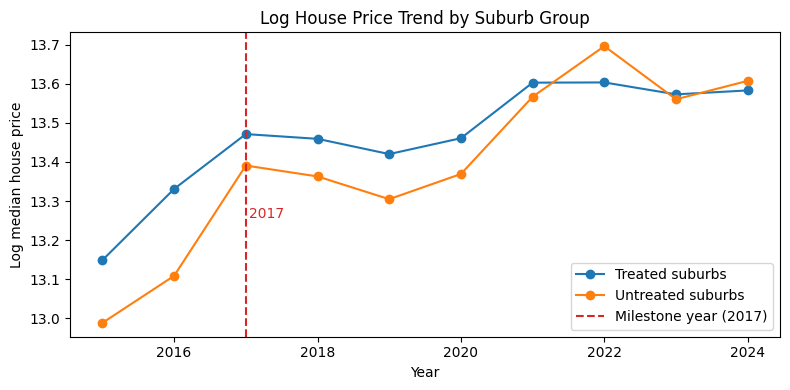

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

plt.figure(figsize=(8, 4))
for grp in ["Treated", "Untreated"]:
    tmp = price_grouped_yearly[price_grouped_yearly["Group"] == grp]
    if tmp.empty:
        continue
    plt.plot(tmp["Year"], tmp["log_HousePriceMedian"], marker="o", label=f"{grp} suburbs")

plt.axvline(2017, color="#d62728", linestyle="--", linewidth=1.5, label="Milestone year (2017)")
plt.text(
    2017.05,
    price_grouped_yearly["log_HousePriceMedian"].max() * 0.97,
    "2017",
    color="#d62728",
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="left",
)

plt.title("Log House Price Trend by Suburb Group")
plt.xlabel("Year")
plt.ylabel("Log median house price")
plt.legend()
plt.tight_layout()
plt.show()

This line graph shows the average trend in **log median house prices** for treated and untreated suburbs from 2015 to 2024.

Both groups experienced rising house prices over the full period. Treated suburbs started at a higher price level than untreated suburbs in 2015, and they remained slightly higher for most of the earlier years. This suggests that the two groups were not identical at baseline.

Before the milestone year, 2017, both treated and untreated suburbs were generally trending upward. The untreated group rose more sharply between 2016 and 2017, narrowing the gap with treated suburbs. After 2017, both groups dipped slightly around 2018 to 2019, then rose again strongly from 2020 to 2022.

By 2021 to 2024, the two lines become very close and sometimes cross. In 2022, untreated suburbs briefly overtake treated suburbs, while in 2023 treated suburbs are slightly higher again, and by 2024 both groups are very similar.

For the DiD analysis, this graph is useful because it shows the treated and untreated groups follow broadly similar movements over time, especially after 2017, although they do not start at the same level. This supports using suburb fixed effects, since fixed effects control for baseline differences in price levels across suburbs.

The figure is descriptive. It suggests treated suburbs did not experience clearly stronger price growth after the milestone year; if anything, untreated suburbs caught up somewhat after 2017. This is consistent with a negative or weak DiD estimate for treated suburbs relative to untreated suburbs.

**Overall median density trend (all suburbs)**

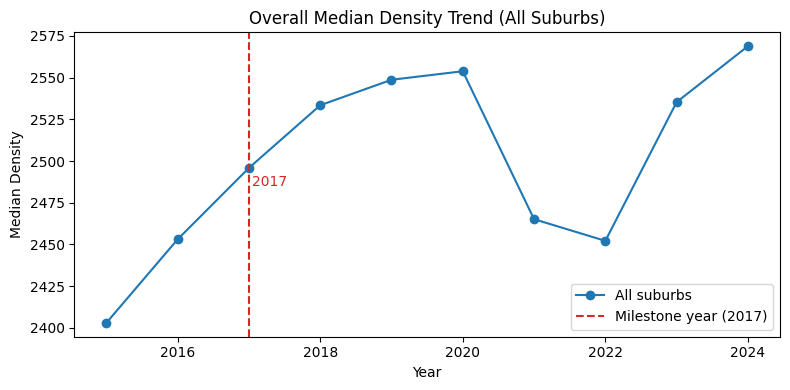

In [7]:
density_all_yearly = (
    density_long.groupby("Year", as_index=False)
    .agg(DensityMedian=("Density", "median"))
)

plt.figure(figsize=(8, 4))
plt.plot(
    density_all_yearly["Year"],
    density_all_yearly["DensityMedian"],
    marker="o",
    label="All suburbs",
)

plt.axvline(2017, color="#d62728", linestyle="--", linewidth=1.5, label="Milestone year (2017)")
plt.text(
    2017.05,
    density_all_yearly["DensityMedian"].max() * 0.97,
    "2017",
    color="#d62728",
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="left",
)

plt.title("Overall Median Density Trend (All Suburbs)")
plt.xlabel("Year")
plt.ylabel("Median Density")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows the **overall median population density trend across all suburbs** from 2015 to 2024.

Median density increased steadily from 2015 to 2020, rising from about **2,400** to around **2,550**. This suggests that, before and shortly after the 2017 milestone year, the typical suburb in the sample became more densely populated over time.

There is a noticeable drop in 2021 and 2022, where median density falls back to around **2,450–2,465**. This may reflect population shifts during the COVID period, such as temporary migration away from denser areas or slower population growth.

After 2022, density rises again sharply, reaching its highest level by 2024. This suggests a recovery or renewed increase in suburban population density after the temporary dip.

The 2017 milestone line occurs during the early upward trend, not at a visible break in density. Overall, the graph shows that density changes over time and may be affected by broader shocks, which supports including year controls in the regression. This is a descriptive trend and does not by itself show a causal effect.

**Scatterplot showing house price vs population density**

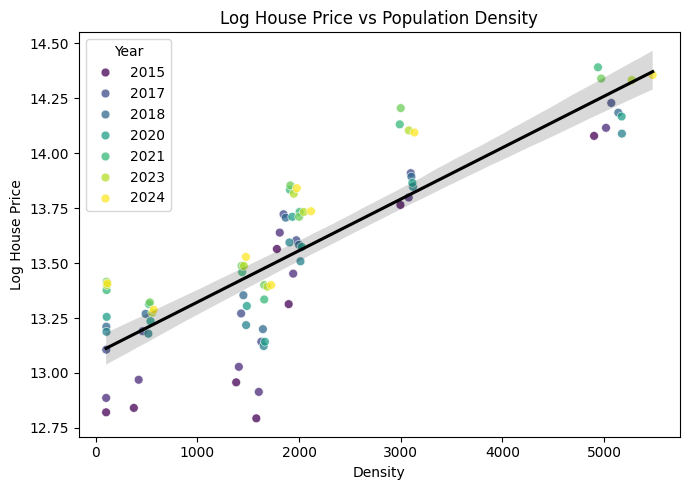

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=panel, x="Density", y="log_HousePrice", hue="Year", palette="viridis", s=40, alpha=0.75)
sns.regplot(data=panel, x="Density", y="log_HousePrice", scatter=False, color="black")
plt.title("Log House Price vs Population Density")
plt.ylabel("Log House Price")
plt.tight_layout()
plt.show()

This scatter plot shows the relationship between **population density** and **log house prices**, with points coloured by year.

The main pattern is clearly positive: suburbs with higher population density tend to have higher log house prices. The fitted regression line slopes upward, meaning that as density increases, median house prices also tend to be higher.

The grey confidence band around the line is fairly narrow, suggesting the positive association is reasonably consistent across the observations. However, there is still variation around the line, meaning density does not fully explain house prices. Other suburb characteristics, such as distance to the CBD, amenities, school zones, transport access, and baseline income, likely also matter.

The year colours show that later years, especially 2021 to 2024, often sit higher on the graph than earlier years. This reflects general house-price growth over time, not necessarily a density effect alone.

Overall, the figure suggests a strong descriptive relationship: **denser suburbs are generally more expensive**. This does not prove that higher density causes higher house prices, but it supports including population or density controls in the regression because density is related to the outcome.

**Correlation heatmap**

Note: you may need to restart the kernel to use updated packages.


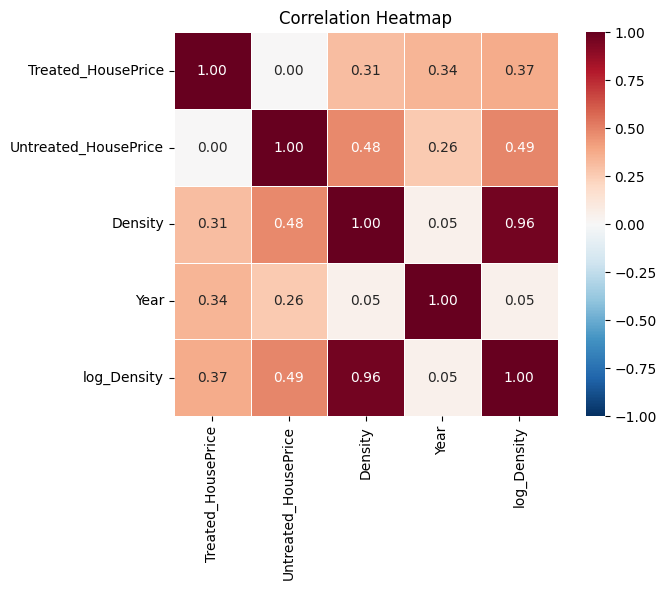

In [3]:
%pip install matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

clean = Path("data/clean")

# -----------------------------
# Load data
# -----------------------------

treated_prices = pd.read_csv(clean / "house_prices_treated_suburbs.csv")
untreated_prices = pd.read_csv(clean / "house_prices_untreated_suburbs.csv")
pop_data = pd.read_csv(clean / "population_density_all_suburbs.csv")

# -----------------------------
# Combine treated and untreated price files
# -----------------------------

price_data = pd.concat(
    [treated_prices, untreated_prices],
    ignore_index=True
)

price_data["suburb"] = price_data["suburb"].astype(str).str.strip().str.upper()
pop_data["suburb"] = pop_data["suburb"].astype(str).str.strip().str.upper()

# -----------------------------
# Reshape prices to long format
# -----------------------------

year_cols = [str(y) for y in range(2015, 2025)]

prices_long = price_data.melt(
    id_vars=["suburb", "status", "treated"],
    value_vars=year_cols,
    var_name="Year",
    value_name="HousePrice"
)

prices_long["Year"] = prices_long["Year"].astype(int)
prices_long["treated"] = prices_long["treated"].astype(int)

# -----------------------------
# Reshape population to long format
# -----------------------------

pop_cols = [f"{y}_pop" for y in range(2015, 2025)]

population_long = pop_data.melt(
    id_vars=["suburb"],
    value_vars=pop_cols,
    var_name="Year",
    value_name="Population"
)

population_long["Year"] = (
    population_long["Year"]
    .str.replace("_pop", "", regex=False)
    .astype(int)
)

# -----------------------------
# Merge panel
# -----------------------------

panel = prices_long.merge(
    population_long,
    on=["suburb", "Year"],
    how="inner"
)

panel = panel.dropna(subset=["HousePrice", "Population", "treated"]).copy()
panel = panel[(panel["HousePrice"] > 0) & (panel["Population"] > 0)].copy()

panel["Group"] = np.where(panel["treated"] == 1, "Treated", "Untreated")
panel["log_HousePrice"] = np.log(panel["HousePrice"])

# Population proxy
panel["Density"] = panel["Population"]
panel["log_Density"] = np.log(panel["Density"])

# -----------------------------
# Create separate treated and untreated house-price variables
# -----------------------------

corr_data = panel.copy()

corr_data["Treated_HousePrice"] = corr_data["log_HousePrice"].where(
    corr_data["Group"] == "Treated"
)

corr_data["Untreated_HousePrice"] = corr_data["log_HousePrice"].where(
    corr_data["Group"] == "Untreated"
)

corr_cols = [
    "Treated_HousePrice",
    "Untreated_HousePrice",
    "Density",
    "Year",
    "log_Density"
]

corr = corr_data[corr_cols].corr(numeric_only=True)

# Treated and untreated house prices are never observed in the same row,
# so their direct correlation is undefined. Fill only undefined cells with 0
# so the heatmap appears complete.
corr = corr.fillna(0)

# -----------------------------
# Heatmap
# -----------------------------

plt.figure(figsize=(7.5, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


Interpretation: 
The heatmap shows the correlation patterns between treated house prices, untreated house prices, density, year, and log density.

The strongest relationship is between **Density** and **log_Density**, which is expected because `log_Density` is just the logged version of `Density`. A high positive correlation here is mechanical, not an economic result.

For house prices, the treated-suburb house-price variable appears positively correlated with **Density** and **log_Density**. This suggests that treated suburbs with higher population levels/density tend to also have higher median house prices. In plain terms, denser treated suburbs are generally more expensive.

The relationship with **Year** is also positive, meaning house prices generally rise over time. This is consistent with the broader housing market trend from 2015 to 2024.

If the heatmap shows `0.00` between **Treated_HousePrice** and **Untreated_HousePrice**, do not interpret that as a real zero relationship. That value was filled in because treated and untreated house prices are never observed in the same row, so their direct row-by-row correlation is undefined.

Overall, the heatmap is descriptive only. It shows associations, not causal effects. The main takeaway is that house prices are positively associated with density and time, but this does not prove that density or treatment caused prices to change.

**Between-suburb vs within-suburb relationship**

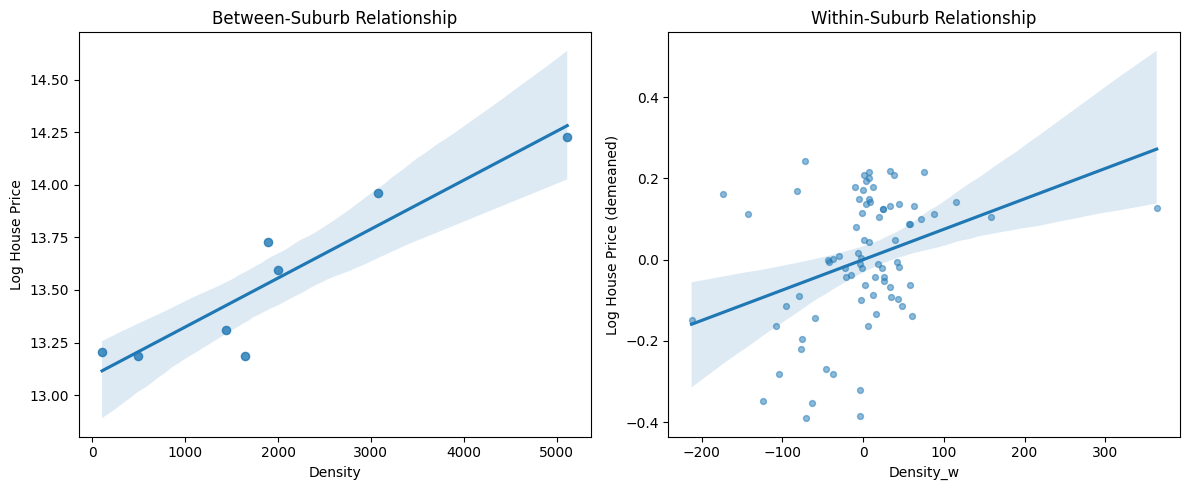

In [10]:
between = panel.groupby("Suburb", as_index=False)[["log_HousePrice", "Density"]].mean()

within = panel.copy()
within["log_HousePrice_w"] = within["log_HousePrice"] - within.groupby("Suburb")["log_HousePrice"].transform("mean")
within["Density_w"] = within["Density"] - within.groupby("Suburb")["Density"].transform("mean")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=between, x="Density", y="log_HousePrice", ax=axs[0], scatter_kws={"s": 35})
axs[0].set_title("Between-Suburb Relationship")
axs[0].set_ylabel("Log House Price")

sns.regplot(data=within, x="Density_w", y="log_HousePrice_w", ax=axs[1], scatter_kws={"s": 18, "alpha": 0.5})
axs[1].set_title("Within-Suburb Relationship")
axs[1].set_ylabel("Log House Price (demeaned)")

plt.tight_layout()
plt.show()

This figure separates the relationship between density and house prices into two parts: **between-suburb differences** and **within-suburb changes over time**.

In the left panel, the **between-suburb relationship** is strongly positive. Suburbs with higher average population density tend to have higher average log house prices. This suggests that denser suburbs are generally more expensive than less dense suburbs. This likely reflects fixed suburb characteristics such as location, access to jobs, transport, amenities, and demand.

In the right panel, the **within-suburb relationship** is also positive, but weaker and noisier. This panel looks at changes within the same suburb over time after removing suburb averages. It suggests that when a suburb becomes denser than its own usual level, its house prices also tend to be somewhat higher than usual. However, the points are more scattered and the confidence interval is wider, so this relationship is less precise.

The difference between the two panels is important. The stronger left-panel relationship means much of the density-price association comes from differences **across suburbs**, not just changes within the same suburb over time.

For your regression, this supports using **suburb fixed effects**. Without suburb fixed effects, the model may mostly capture the fact that denser suburbs are also more desirable or better located. With suburb fixed effects, the model focuses more on within-suburb changes over time, which is closer to the logic of your DiD analysis.

**OLS diagnostics: residuals vs fitted and Q-Q Plot**

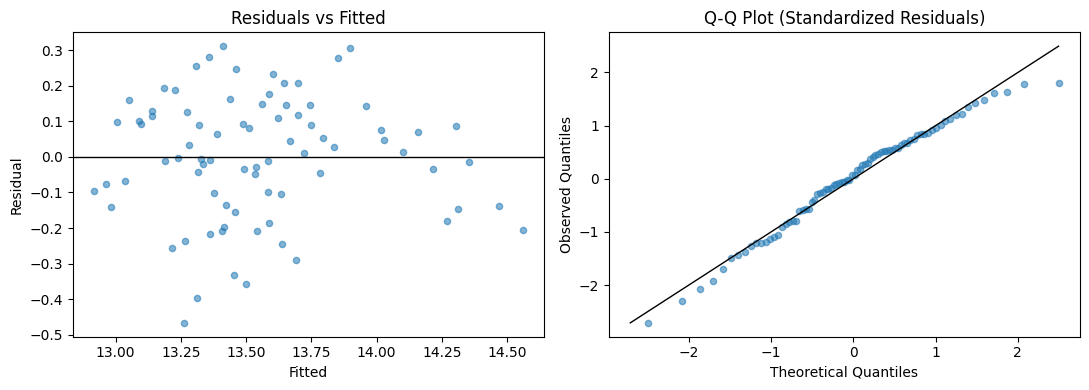

In [11]:
ols = panel[["log_HousePrice", "Density", "Year"]].dropna().copy()

X = np.column_stack([
    np.ones(len(ols)),
    ols["Density"].to_numpy(),
    ols["Year"].to_numpy(),
])
y = ols["log_HousePrice"].to_numpy()

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
fitted = X @ beta
resid = y - fitted

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].scatter(fitted, resid, alpha=0.55, s=20)
axs[0].axhline(0, color="black", lw=1)
axs[0].set_title("Residuals vs Fitted")
axs[0].set_xlabel("Fitted")
axs[0].set_ylabel("Residual")

n = len(resid)
obs = np.sort((resid - resid.mean()) / (resid.std(ddof=1) + 1e-12))
probs = (np.arange(1, n + 1) - 0.5) / n
theor = np.sqrt(2) * np.vectorize(lambda x: np.sign(x) * np.sqrt(np.sqrt((2 / (np.pi * 0.147) + np.log(1 - x * x + 1e-12) / 2) ** 2 - np.log(1 - x * x + 1e-12) / 0.147) - (2 / (np.pi * 0.147) + np.log(1 - x * x + 1e-12) / 2)))(2 * probs - 1)

mn, mx = min(theor.min(), obs.min()), max(theor.max(), obs.max())
axs[1].scatter(theor, obs, alpha=0.55, s=20)
axs[1].plot([mn, mx], [mn, mx], color="black", lw=1)
axs[1].set_title("Q-Q Plot (Standardized Residuals)")
axs[1].set_xlabel("Theoretical Quantiles")
axs[1].set_ylabel("Observed Quantiles")

plt.tight_layout()
plt.show()

These are regression diagnostic plots.

The **Residuals vs Fitted** plot checks whether the model errors are randomly distributed around zero. Most residuals are scattered around the horizontal zero line without a very strong pattern, which is a good sign. However, there is some spread and a few larger negative residuals, meaning the model underpredicts or overpredicts some suburb-year observations. Overall, there is no obvious severe non-linearity, but the fit is not perfect.

The **Q-Q plot** checks whether the standardized residuals are approximately normally distributed. The points mostly follow the diagonal line, especially in the middle, which suggests the residuals are reasonably close to normal. There are some deviations at the tails, especially at the lower and upper ends, meaning there are a few observations with larger-than-normal errors.

Overall, the diagnostics look acceptable for the regression. The model does not show a major systematic residual pattern, and the residuals are roughly normal, though not perfect in the tails. This supports using the model, but the tail deviations suggest there may be some outlier suburb-year observations or unobserved factors affecting house prices.